In [1]:
import sys

sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np

from python.model import BaseModel
from python.data import SyntheticDataGenerator

In [2]:
dataset_generator = SyntheticDataGenerator(noise_proba=0.0, proba_neutral_items=0.12)
dataset = dataset_generator.generate_synthetic_dataset(n_baskets=100000)

In [3]:
dataset = [i for i in dataset if len(i) > 1]

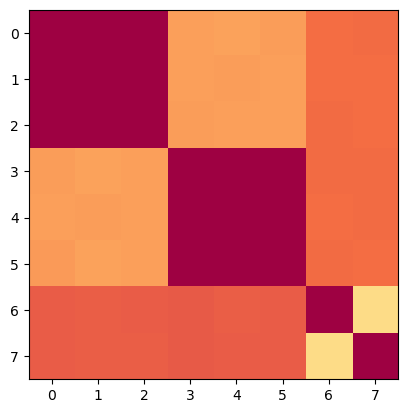

In [4]:
interactions = np.zeros((8, 8))
for i in range(8):
    count = 9
    for bsk in dataset:
        if i in bsk:
            count += 1
            for j in range(8):
                if i!= j and j in bsk:
                    interactions[i][j] += 1
    interactions[i] = interactions[i] / count

plt.imshow(interactions, vmin=0.0, vmax=1.0, cmap="Spectral")

In [5]:
interactions

array([[0.        , 0.        , 0.        , 0.27794242, 0.282035  ,
        0.27377928, 0.20110076, 0.19665538],
       [0.        , 0.        , 0.        , 0.27959908, 0.2747268 ,
        0.28050393, 0.2025475 , 0.19983295],
       [0.        , 0.        , 0.        , 0.27667736, 0.27849072,
        0.27800251, 0.19877249, 0.20079509],
       [0.27692632, 0.28241001, 0.27889483, 0.        , 0.        ,
        0.        , 0.19649888, 0.19565523],
       [0.28080652, 0.2772938 , 0.2805255 , 0.        , 0.        ,
        0.        , 0.2016299 , 0.19734439],
       [0.27220429, 0.28272766, 0.2796408 , 0.        , 0.        ,
        0.        , 0.19854076, 0.20001403],
       [0.16715543, 0.17067449, 0.16715543, 0.16392962, 0.16832845,
        0.1659824 , 0.        , 0.39214076],
       [0.1640763 , 0.16902155, 0.16949252, 0.16384081, 0.16537148,
        0.16784411, 0.39361827, 0.        ]])

In [6]:
model1 = BaseModel(epochs=5, lr=0.1, embedding_dim=4, k_noise=4, batch_size=256)
model1.fit(dataset, repr = True)

Training Epochs:   0%|          | 0/5 [00:00<?, ?it/s]


AttributeError: 'list' object has no attribute 'shape'

Training Epochs: 100%|██████████| 5/5 [1:11:56<00:00, 863.24s/it, epoch_loss=2.46e+5]

Training completed. Final loss: 246321.22400665283


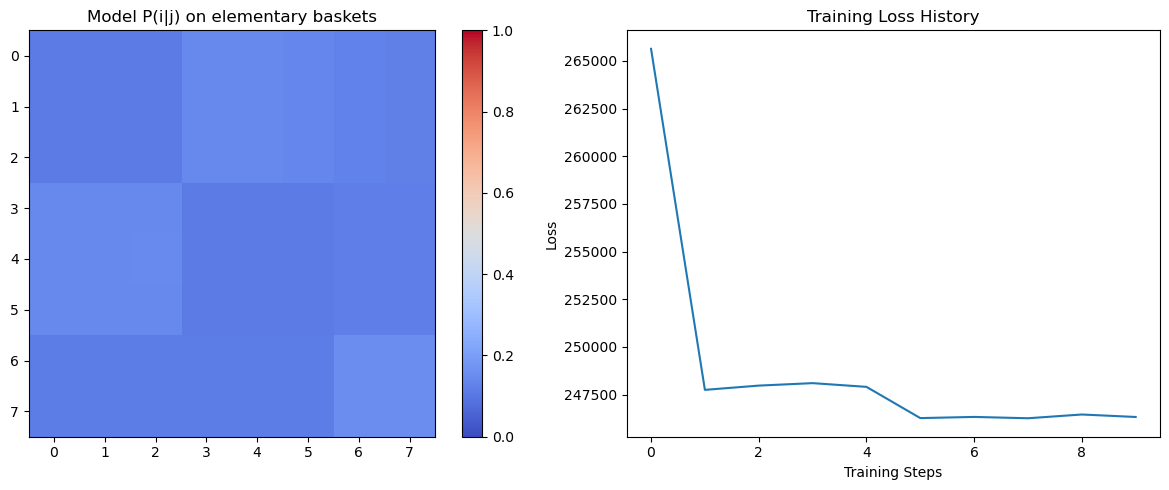

      Model Parameters
Embedding_dim       : 4
K_noise             : 4
Learning_rate       : 0.1
Epochs              : 5
Loss type           : nce


In [ ]:
# model1.optimizer.learning_rate = model1.optimizer.learning_rate / 10
# model1.fit(dataset, repr = True)

Training Epochs: 100%|██████████| 25/25 [3:31:54<00:00, 508.56s/it, epoch_loss=2.48e+4]   

Training completed. Final loss: 24816.671298980713


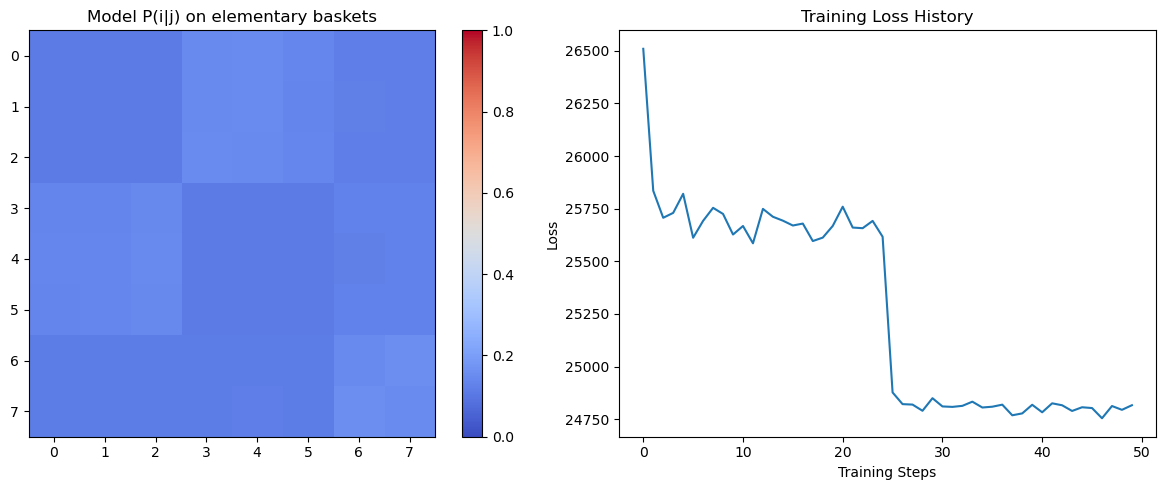

      Model Parameters
Embedding_dim       : 4
K_noise             : 4
Learning_rate       : 0.1
Epochs              : 25
Loss type           : nce


In [ ]:
model1.optimizer.learning_rate = model1.optimizer.learning_rate / 10
model1.fit(dataset, repr = True)

[[0.   0.   0.   0.27 0.19 0.24 0.17 0.12]
 [0.   0.   0.   0.28 0.19 0.26 0.16 0.11]
 [0.   0.   0.   0.27 0.2  0.26 0.16 0.11]
 [0.27 0.32 0.24 0.   0.   0.   0.09 0.08]
 [0.25 0.28 0.23 0.   0.   0.   0.12 0.12]
 [0.25 0.32 0.24 0.   0.   0.   0.09 0.09]
 [0.07 0.06 0.07 0.03 0.03 0.03 0.36 0.35]
 [0.05 0.04 0.05 0.05 0.05 0.05 0.36 0.35]]


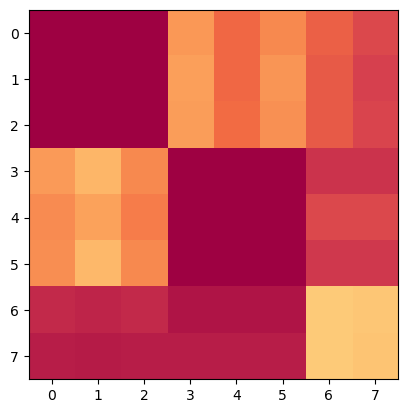

In [ ]:
ValueS = np.stack([model1.predict([i]) for i in range(8)])
print(np.round(ValueS, 2))
plt.imshow(ValueS, cmap="Spectral", vmin=0, vmax=1)

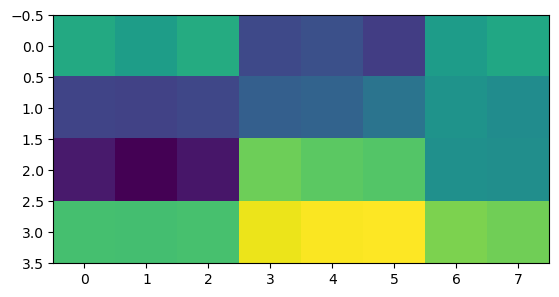

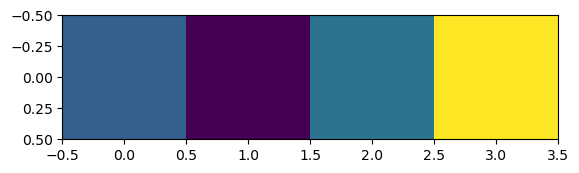

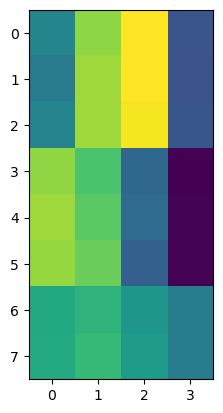

In [ ]:
plt.imshow(model1.trainable_weights[0])
plt.show()
plt.imshow([model1.trainable_weights[1]])
plt.show()
plt.imshow(model1.trainable_weights[2])
plt.show()

In [ ]:
model1.trainable_weights

[<tf.Variable 'Wi:0' shape=(4, 8) dtype=float32, numpy=
 array([[ 0.24663012,  0.03309557,  0.2791443 , -1.3764366 , -1.2829444 ,
         -1.5436709 ,  0.01053036,  0.1984119 ],
        [-1.4387741 , -1.4785212 , -1.4019845 , -1.0254674 , -0.9714156 ,
         -0.69069695, -0.14831762, -0.2680406 ],
        [-1.9906393 , -2.300625  , -2.0504904 ,  0.96055514,  0.8328463 ,
          0.77081466, -0.19745733, -0.22921284],
        [ 0.6587794 ,  0.6294266 ,  0.66615903,  1.7684317 ,  1.8583412 ,
          1.8873706 ,  1.0656288 ,  0.97221553]], dtype=float32)>,
 <tf.Variable 'wa:0' shape=(4,) dtype=float32, numpy=array([-0.7743383 , -1.4707249 , -0.60153055,  0.80201966], dtype=float32)>,
 <tf.Variable 'Wo:0' shape=(8, 4) dtype=float32, numpy=
 array([[-0.25896826,  1.9052447 ,  2.892892  , -1.3673832 ],
        [-0.54320794,  2.0344088 ,  2.887083  , -1.4213026 ],
        [-0.32184255,  2.0410936 ,  2.805648  , -1.3509974 ],
        [ 1.9263358 ,  1.2587266 , -0.9723622 , -2.903424  ],


In [ ]:
import tensorflow as tf

In [ ]:
ctx = [0, 6]

In [ ]:
tf.gather(model1.Wi, ctx, axis=1)

<tf.Tensor: shape=(4, 2), dtype=float32, numpy=
array([[ 0.01196236, -0.4631864 ],
       [ 0.49076775,  0.16381513],
       [ 2.1600006 ,  0.5222465 ],
       [-0.36178884, -0.12936231]], dtype=float32)>

In [ ]:
attn_logits = tf.tensordot(model1.wa, tf.gather(model1.Wi, ctx, axis=1), axes=1)
attn_logits

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([3.4435976, 1.5420101], dtype=float32)>

In [ ]:
    def context_embed(self, context_items: list) -> tf.Tensor:
        """Returns the context embedding matrix. [self.embedding_dim]"""

        context_items = tf.convert_to_tensor(context_items, dtype=tf.int32)
        context_emb = tf.gather(self.Wi, context_items, axis=1)
        attn_logits = tf.tensordot(self.wa, context_emb, axes=1)
        attn_weights = tf.nn.softmax(attn_logits)
        context_vec = tf.reduce_sum(
            context_emb * tf.expand_dims(attn_weights, axis=0), axis=1
        )
        return context_vec